In [1]:
%load_ext autoreload
%autoreload 2



## setup the schema

In [2]:
import os
import os
import datajoint as dj
from djimaging.user.ssuhai.schemas.ssuhai_schema import *
from djimaging.utils.dj_utils import activate_schema
import warnings
warnings.simplefilter("ignore", FutureWarning)


In [3]:
username = !whoami
username = username[0]
home_directory = os.path.expanduser("~")
path_to_djimaging = f'{home_directory}/GitRepos'
config_file = f'{home_directory}/datajoint/dj_{username}_conf.json'
assert os.path.isfile(config_file), f'Set the path to your config file: {config_file}'
schema_name = f"ageuler_{username}_test"


In [4]:
# Load configuration for user
dj.config.load(config_file)
dj.config['schema_name'] = schema_name

print("schema_name:", dj.config['schema_name'])
dj.conn()

[2025-04-16 13:25:51,071][INFO]: Connecting ssuhai@172.25.240.200:3306


[2025-04-16 13:25:51,132][INFO]: Connected ssuhai@172.25.240.200:3306


schema_name: ageuler_ssuhai_test


DataJoint connection (connected) ssuhai@172.25.240.200:3306

In [5]:
activate_schema(schema=schema, create_schema=True, create_tables=True)


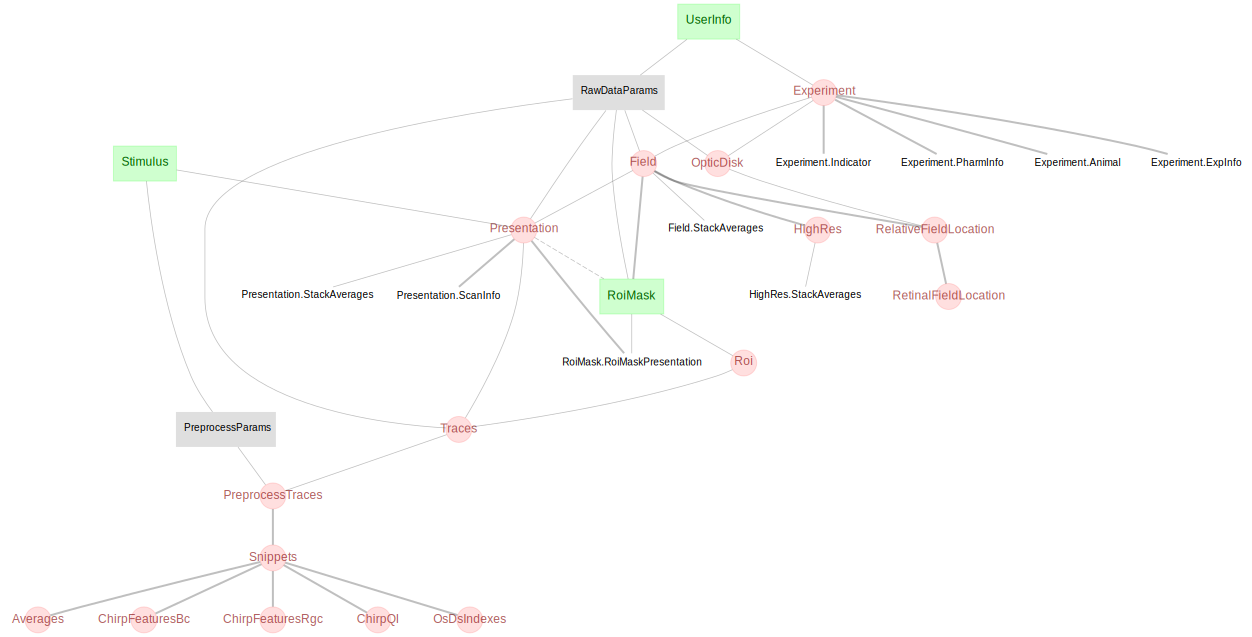

In [6]:
dj.ERD(schema)

## First iter


In [7]:
# 1. Set initial user info

userinfo = {
    'experimenter': 'closedlooptest', # Replace this if you want to use your own data
    'data_dir': '/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/recordings/updated_loop_data', # Replace this if you want to use your own data
    'datatype_loc': 0,
    'animal_loc': 1,
    'region_loc': 2,
    'field_loc': 3,
    'stimulus_loc': 4,
    'cond1_loc': 5,
}


### Populate some tables

In [117]:
UserInfo().upload_user(userinfo)


# 2. set parameters for Raw data
# raw_params_dict = {
#     'experimenter': 'closedlooptest',
#     'raw_id': 1,
#     'from_raw_data': 1, 
#     'compute_from_stack': 1,
#     'include_artifacts': 0,
#     'trace_precision': 'line',
#     'trigger_precision': 'line',
#     'igor_roi_masks': 'no'
#     }
if len(RawDataParams()) == 0:
    RawDataParams().add_default()
RawDataParams().update1(dict(experimenter='closedlooptest',raw_id=int(1),
                             from_raw_data=int(1),
                             igor_roi_masks='no',
                             ))



Experiment().rescan_filesystem(verboselvl=3)
Field().rescan_filesystem(verboselvl=3)


# # TODO add dynamic
# Stimulus().add_chirp(spatialextent=1000, stim_name='gChirp', alias="chirp_gchirp_globalchirp", skip_duplicates=True)

# lets try my custom stimlulus
Stimulus().add_stimulus(stim_name='closedloop1', alias="closedloop1_cl1_firstclosedloop", isrepeated=True, ntrigger_rep=2,
                        trial_info=[1, 2], skip_duplicates=True)


Presentation().populate(processes=20, display_progress=True)


Scanning for experimenter: closedlooptest
	header_path: /gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/recordings/updated_loop_data/20250412/1
		header_name: 20190701__left.ini
		Adding: {'experimenter': 'closedlooptest', 'date': datetime.datetime(2025, 4, 12, 0, 0), 'exp_num': 1}
Found 1 files in 1 fields for key={'experimenter': 'closedlooptest', 'date': datetime.date(2025, 4, 12), 'exp_num': 1, 'raw_id': 1}
	Adding field: `{'field': 'GCL0', 'region': 'LR', 'cond1': 'iter1', 'experimenter': 'closedlooptest', 'date': datetime.date(2025, 4, 12), 'exp_num': 1, 'raw_id': 1}`


Presentation: 100%|██████████| 1/1 [00:01<00:00,  1.98s/it]


{'success_count': 1, 'error_list': []}

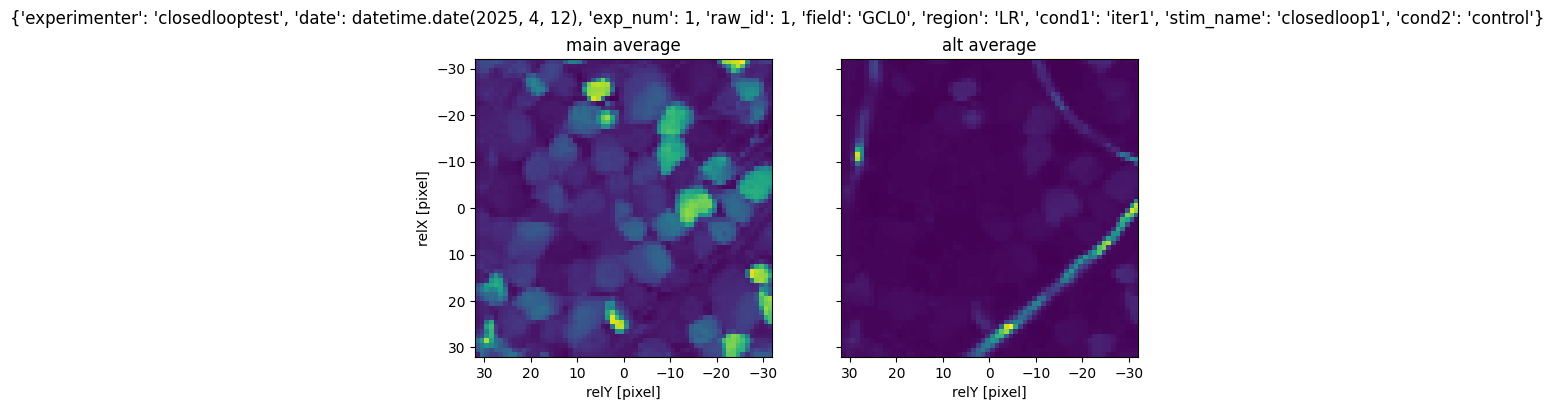

In [118]:
Presentation().plot1()

### autorois

In [ ]:
# load ROI masks if they exist
RoiMask().rescan_filesystem(verboselvl=3)
missing_fields = RoiMask().list_missing_field()
field_key = missing_fields[0]

# TODO
# somehow there is an error in getting some property of the loaded smp file object 
# but the error occurs in the SMH class. Some dict key is not found.
roi_canvas = RoiMask().draw_roi_mask(field_key=field_key, canvas_width=30)
roi_canvas.start_gui()


field_key: {'experimenter': 'closedlooptest', 'date': datetime.date(2025, 4, 12), 'exp_num': 1, 'raw_id': 1, 'field': 'GCL0', 'region': 'LR', 'cond1': 'iter1'} 
pres_keys: [{'experimenter': 'closedlooptest', 'date': datetime.date(2025, 4, 12), 'exp_num': 1, 'raw_id': 1, 'field': 'GCL0', 'region': 'LR', 'cond1': 'iter1', 'stim_name': 'closedloop1', 'cond2': 'control'}]
No ROI masks found for field: {'experimenter': 'closedlooptest', 'date': datetime.date(2025, 4, 12), 'exp_num': 1, 'raw_id': 1, 'field': 'GCL0', 'region': 'LR', 'cond1': 'iter1'}
pres_keys: [{'experimenter': 'closedlooptest', 'date': datetime.date(2025, 4, 12), 'exp_num': 1, 'raw_id': 1, 'field': 'GCL0', 'region': 'LR', 'cond1': 'iter1', 'stim_name': 'closedloop1', 'cond2': 'control'}]


Load model weights for cpu from checkpoint /gpfs01/euler/data/Resources/AutoROIs/models/UNET_v0.1.0/dropout_and_aug_regul.ckpt using config /gpfs01/euler/data/Resources/AutoROIs/models/UNET_v0.1.0/sd_images.yaml


Returned InteractiveRoiCanvas object. To start GUI, call <enter_object_name>.start_gui().


In [123]:
roi_canvas.insert_database(roi_mask_tab=RoiMask, field_key=field_key)

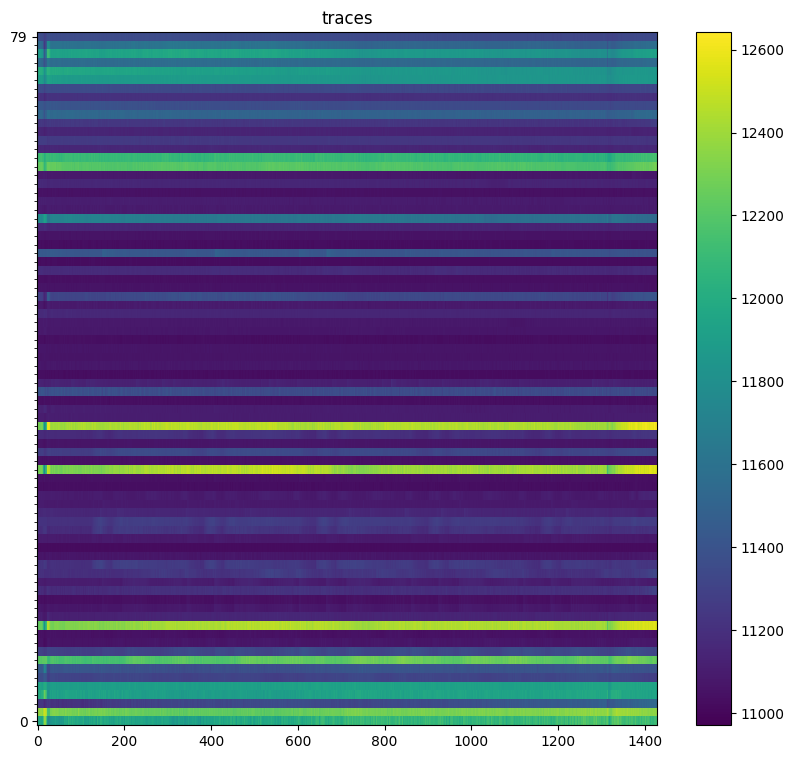

In [127]:
Roi().populate(processes=20, display_progress=True)
Traces().populate(processes=20, display_progress=True)
Traces().plot()

## New loop iteration 

lets try to add another presentation to the presentations table. This seems like the most natural integration into the pipeline

In [131]:
Stimulus()

stim_name Unique string identifier,"alias Strings (_ seperator) to identify this stimulus, not case sensitive!",stim_family To group stimuli (e.g. gChirp and lChirp) for downstream processing,framerate framerate in Hz,isrepeated Is the stimulus repeated? Used for snippets,ntrigger_rep Number of triggers (per repetition),stim_path Path to hdf5 file containing numerical array and info about stim,commit_id Commit id corresponding to stimulus entry in GitHub repo,stim_hash QDSpy hash,"trial_info trial information, e.g. directions of moving bar",stim_trace array of stimulus if available,"stim_dict stimulus information dictionary, contains e.g. spatial extent",snippet_base_dt Time used for snippet baseline estimation
closedloop1,closedloop1_cl1_firstclosedloop,,0.0,1,2,,,,=BLOB=,=BLOB=,=BLOB=,nan
closedloop2,closedloop2_cl2_secondclosedloop,,0.0,1,2,,,,=BLOB=,=BLOB=,=BLOB=,nan


first move more files to simulate additional presentation 
the only thing that changes is the stimulus name. I did this in the terminal 

Rescaning fields does not do anything because it we already have a field 

It seems like we cannot add the same chirp again. 
If we give it random aliases then the process loading the stimulus file
gives an error because the stimlulus file does not have my random alias. 
Lets try to add a noise stimulus:
it also does not work with the noise stimlulus to add the same stimulus again
There seem to be two options: 1) create an own stmulus or 
2) go with one different experiment per closed loop iteration
Since sooner or later I probably have to do own stimuli anyway, I will go try option 1)
It seems to be simple to add an own stimlulus lets see if we can simply add a second one.
That seemed to work. we see a second row in the presentations table. 

Next lets copy the roi masks and try to populate traces again. Okay that did not work. We still have to insert the ROIs in RoiMask. Lets just call the gui again and after copying the roi mask and use the .insertdatabase method. Hopwfully this will also take care of dependencies between tables such as with the Field table, which is linked to the RoiMasks table. 

WOOOOW! conditions can be added at the index 4 of the file name. this changes everything. I can maybe see the condition as loop iteration. 





In [71]:
noise_dict = (Stimulus() & 'stim_name="noise"').fetch1()
noise_dict.keys()

dict_keys(['stim_name', 'alias', 'stim_family', 'framerate', 'isrepeated', 'ntrigger_rep', 'stim_path', 'commit_id', 'stim_hash', 'trial_info', 'stim_trace', 'stim_dict', 'snippet_base_dt'])

In [128]:
Field().rescan_filesystem(verboselvl=3)

Found 2 files in 2 fields for key={'experimenter': 'closedlooptest', 'date': datetime.date(2025, 4, 12), 'exp_num': 1, 'raw_id': 1}
	Skipping field `{'field': 'GCL0', 'region': 'LR', 'cond1': 'iter1', 'experimenter': 'closedlooptest', 'date': datetime.date(2025, 4, 12), 'exp_num': 1, 'raw_id': 1}` because it already exists
	Adding field: `{'field': 'GCL0', 'region': 'LR', 'cond1': 'iter2', 'experimenter': 'closedlooptest', 'date': datetime.date(2025, 4, 12), 'exp_num': 1, 'raw_id': 1}`


In [129]:
# Add custom stimulus if needed
Stimulus().add_stimulus(stim_name='closedloop2', alias="closedloop2_cl2_secondclosedloop", isrepeated=True, ntrigger_rep=2,
                        trial_info=[1, 2], skip_duplicates=True)

In [130]:
# next populate presentations.
Presentation().populate()

{'success_count': 3, 'error_list': []}

In [132]:
# this seemed to work
Presentation()

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),stim_name Unique string identifier,cond2 condition (pharmacological or other),pres_data_file path to file (e.g. h5 file),triggertimes triggertimes in each presentation,trigger_valid Are triggers as expected (1) or not (0)?,absx absolute position of the center (of the cropped field) in the x axis as recorded by ScanM,absy absolute position of the center (of the cropped field) in the y axis as recorded by ScanM,absz absolute position of the center (of the cropped field) in the z axis as recorded by ScanM,scan_type Type of scan,npixartifact number of pixel with light artifact,nxpix number of pixels in x,nypix number of pixels in y,nzpix number of pixels in z,nxpix_offset number of offset pixels in x,nxpix_retrace number of retrace pixels in x,pixel_size_um width of a pixel in um (also height if y is second dimension),z_step_um z-step in um,nframes number of pixels in time
closedlooptest,2025-04-12,1,1,GCL0,LR,iter1,closedloop1,control,/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/recordings/updated_loop_data/20250412/1/Raw/M1_LR_GCL0_cl1_iter1.smp,=BLOB=,1,979.24,-2575.6,1645.9,xy,3,64,64,1,6,10,1.46998,nan,1429
closedlooptest,2025-04-12,1,1,GCL0,LR,iter2,closedloop1,control,/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/recordings/updated_loop_data/20250412/1/Raw/M1_LR_GCL0_cl1_iter2.smp,=BLOB=,1,979.24,-2575.6,1645.9,xy,3,64,64,1,6,10,1.46998,nan,1429


In [134]:

# load ROI masks if they exist
RoiMask().rescan_filesystem(verboselvl=3)
missing_fields = RoiMask().list_missing_field()
field_key = missing_fields[0]



field_key: {'experimenter': 'closedlooptest', 'date': datetime.date(2025, 4, 12), 'exp_num': 1, 'raw_id': 1, 'field': 'GCL0', 'region': 'LR', 'cond1': 'iter2'} 
pres_keys: [{'experimenter': 'closedlooptest', 'date': datetime.date(2025, 4, 12), 'exp_num': 1, 'raw_id': 1, 'field': 'GCL0', 'region': 'LR', 'cond1': 'iter2', 'stim_name': 'closedloop1', 'cond2': 'control'}]
No ROI masks found for field: {'experimenter': 'closedlooptest', 'date': datetime.date(2025, 4, 12), 'exp_num': 1, 'raw_id': 1, 'field': 'GCL0', 'region': 'LR', 'cond1': 'iter2'}
pres_keys: [{'experimenter': 'closedlooptest', 'date': datetime.date(2025, 4, 12), 'exp_num': 1, 'raw_id': 1, 'field': 'GCL0', 'region': 'LR', 'cond1': 'iter2', 'stim_name': 'closedloop1', 'cond2': 'control'}]


In [ ]:
# next we need to reuse the Roi mask somehow
# lets try to do this by just copying the roi mask pkl file and renaming it to match the new stimlus name.
# i did this in the shell. Next we can inserting another row in the RoiMask table


# TODO
# somehow there is an error in getting some property of the loaded smp file object 
# but the error occurs in the SMH class. Some dict key is not found.
roi_canvas = RoiMask().draw_roi_mask(field_key=field_key, canvas_width=30)
roi_canvas.start_gui()

Load model weights for cpu from checkpoint /gpfs01/euler/data/Resources/AutoROIs/models/UNET_v0.1.0/dropout_and_aug_regul.ckpt using config /gpfs01/euler/data/Resources/AutoROIs/models/UNET_v0.1.0/sd_images.yaml


Returned InteractiveRoiCanvas object. To start GUI, call <enter_object_name>.start_gui().


In [137]:
roi_canvas.insert_database(roi_mask_tab=RoiMask, field_key=field_key)
Roi().populate(processes=20, display_progress=True)
Traces().populate(processes=20, display_progress=True)

Traces: 100%|██████████| 1/1 [00:02<00:00,  2.05s/it]


{'success_count': 1, 'error_list': []}

In [116]:
def clear_tabels():
    UserInfo().delete()
    Experiment().delete()
    Field().delete()
    Stimulus().delete()
    RoiMask().delete()
    Roi().delete()
    Traces().delete()
    Presentation().delete()
    RawDataParams().delete()

clear_tabels()

[2025-04-16 17:45:48,603][INFO]: Deleting 1 rows from `ageuler_ssuhai_test`.`#raw_data_params`
[2025-04-16 17:45:48,690][INFO]: Deleting 1 rows from `ageuler_ssuhai_test`.`__experiment__animal`
[2025-04-16 17:45:48,754][INFO]: Deleting 1 rows from `ageuler_ssuhai_test`.`__experiment__exp_info`
[2025-04-16 17:45:48,814][INFO]: Deleting 1 rows from `ageuler_ssuhai_test`.`__experiment__indicator`
[2025-04-16 17:45:48,868][INFO]: Deleting 1 rows from `ageuler_ssuhai_test`.`__experiment__pharm_info`
[2025-04-16 17:45:48,904][INFO]: Deleting 1 rows from `ageuler_ssuhai_test`.`__experiment`
[2025-04-16 17:45:48,942][INFO]: Deleting 1 rows from `ageuler_ssuhai_test`.`user_info`
[2025-04-16 17:45:51,515][INFO]: Deletes committed.
[2025-04-16 17:45:51,554][INFO]: Deleting 0 rows from `ageuler_ssuhai_test`.`__experiment`
[2025-04-16 17:45:51,556][WARNING]: Nothing to delete.
[2025-04-16 17:45:51,596][INFO]: Deleting 0 rows from `ageuler_ssuhai_test`.`__field`
[2025-04-16 17:45:51,598][WARNING]: N

In [109]:
if input("Continue with cleaning up? (yes/no))") != "yes":
    raise ValueError('Enter yes if you wish to continue.')

schema.drop()